<a href="https://colab.research.google.com/github/amir-asari/SEBB4083-Assignment2025/blob/main/Mini_Project_G5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Mini Project 2025 (Pain Facial Expression Detection)**

> **Automated Pain Detection using Synthetic Pain Facial Expression Images using Xception CNN Architecture**

### **Total marks:** 15 Marks

### **Group No.:** 5

### **Group Members:**
1) AISYAH MARIYAH BINTI ADZ JAMROS (A22EB0012)

2) MUHAMMAD ISKANDAR BIN MAIZUNIR (A22EB0049)

3) NUR AIN SOFIYA BINTI MOHD HASHIM (A22EB0059)

4) NUR SYAQILLA BINTI RASHADAN (A22EB0073)


## **Chapter 1: Introduction**

This mini group project was carried out as part of the SEBB4083 Artificial Intelligence course. The project focuses on the development of an automated pain detection system using facial expression analysis and deep learning techniques. A transfer learning approach was employed using a pre-trained Xception convolutional neural network, which is well known for its efficiency and strong feature extraction capability in image classification tasks. The model was trained to classify facial images into two categories: Pain and No Pain.

The SynPAIN synthetic facial expression dataset was used in this study to address common challenges in medical data collection, such as privacy concerns, ethical restrictions, and the limited availability of real patient data. By utilising synthetic data, the project aims to evaluate whether reliable pain detection can be achieved without relying on sensitive real-world patient images.

A series of controlled experiments were conducted to analyse the effects of data splitting ratio, data augmentation, and learning rate on the performance of the Xception based model. These experiments were designed to provide insights into model generalisation, training stability, and convergence behaviour. Through this project, the group aimed to strengthen their understanding of deep learning model optimisation, experimental analysis, and the practical application of artificial intelligence in healthcare-related problems.


### **1.1 Background of Study and Related Works**

  Pain assessment is an essential aspect of healthcare, as it directly influences diagnosis and treatment decisions. Traditional pain assessment methods rely on self reporting or verbal communication, which are not suitable for non verbal patients such as infants, individuals with severe dementia, or unconscious patients. In these cases, pain is often underestimated, leading to inadequate treatment. Facial expression analysis has been widely recognised as a reliable non-verbal indicator of pain, as specific facial muscle movements are strongly associated with pain responses and can be objectively analysed using computer vision techniques [1], [2].

  With the advancement of artificial intelligence, deep learning particularly Convolutional Neural Networks (CNNs),has become the preferred approach for facial expression recognition tasks. CNN based models are capable of automatically extracting complex visual features from facial images [3], while transfer learning allows the use of pre-trained networks to achieve high performance with reduced training time and computational cost [4]. However, the development of automated pain detection systems is limited by ethical concerns, privacy issues, and the scarcity of real patient facial data. To address these challenges, Taati et al. (2025) introduced SynPAIN, a synthetic dataset of pain and no pain facial expressions generated using advanced AI techniques [5]. Data augmentation has also been shown to improve model generalisation by increasing training data diversity [6].

  In this mini group project, an automated pain detection system was developed using transfer learning with a pre-trained Xception CNN and the SynPAIN synthetic dataset. The main objective of this study is to analyse the effects of data augmentation and key hyperparameters, specifically data splitting ratio and learning rate, on model performance and training stability. Through systematic experimentation, this project aims to provide insights into effective deep learning training strategies for pain detection using synthetic facial expression data.


### **1.2 Objectives**

The objectives of this mini project, conducted using synthetic facial image data, are as follows:

1) To develop an automated pain detection system that classifies facial images into Pain and No Pain categories using Xception-based convolutional neural network transfer learning.

2) To analyze the impact of data split ratios (70:30, 80:20, and 90:10) on model performance to determine the optimal balance between training volume and validation reliability.

3) To evaluate the effectiveness of data augmentation (rotation, zoom, and flipping) in improving the model's generalization capabilities and reducing overfitting when training on synthetic data.

4) To assess the influence of varying learning rates on the convergence speed and training stability of the Xception model.


## **Chapter 2: Methodology and Results**

## **TASK 1 – DATA ACQUISITION & PREPARATION**

1) Mount Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Explanation:
 This mounts Google Drive into the Colab environment so the dataset can be accessed and saved persistently.

Result:
 Access to files stored in Google Drive.

2) List Drive Contents

In [ ]:
!ls /content/drive

MyDrive


Explanation:
Checks whether the Drive has been mounted successfully and displays available folders.

Result:
 Confirms Drive connection.

3) Download Dataset Using gdown

In [ ]:
!pip install -q gdown
!gdown 1aSs7f0WmEEpVMJlM3eSGA4FhssGHiNxW -O /content/drive/MyDrive/SynPain_Resized.zip

Downloading...
From (original): https://drive.google.com/uc?id=1aSs7f0WmEEpVMJlM3eSGA4FhssGHiNxW
From (redirected): https://drive.google.com/uc?id=1aSs7f0WmEEpVMJlM3eSGA4FhssGHiNxW&confirm=t&uuid=14d3c006-1bec-4c4f-af66-c144d3b28eaf
To: /content/drive/MyDrive/SynPain_Resized.zip
100% 73.0M/73.0M [00:00<00:00, 93.5MB/s]


Explanation:

gdown downloads files from Google Drive using file ID.

The dataset is saved as a ZIP file in MyDrive.

Result:
 Dataset successfully downloaded.

4) Verify Dataset File

In [ ]:
!ls -lh /content/drive/MyDrive/SynPain_Resized.zip

-rw------- 1 root root 70M Dec  9 08:04 /content/drive/MyDrive/SynPain_Resized.zip


Explanation:
Displays file size and confirms the ZIP file exists.

Result:
 Dataset integrity verified.

5) Extract Dataset

In [ ]:
import zipfile

zip_path = "/content/drive/MyDrive/SynPain_Resized.zip"
extract_path = "/content/drive/MyDrive/"

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

Explanation:
Unzips the dataset into a folder containing class directories.

Result:
 Dataset extracted.

6) Verify Dataset Structure

In [ ]:
import os
os.listdir("/content/drive/MyDrive/SynPain_Resized")

['NoPain', 'Pain']

Explanation:
Confirms that the dataset contains Pain and NoPain folders.

Result:
 Correct class structure detected.

7) List Drive Again

In [ ]:
!ls /content/drive

MyDrive


Explanation:
Ensures extraction was successful.

8) Display Sample Pain Images

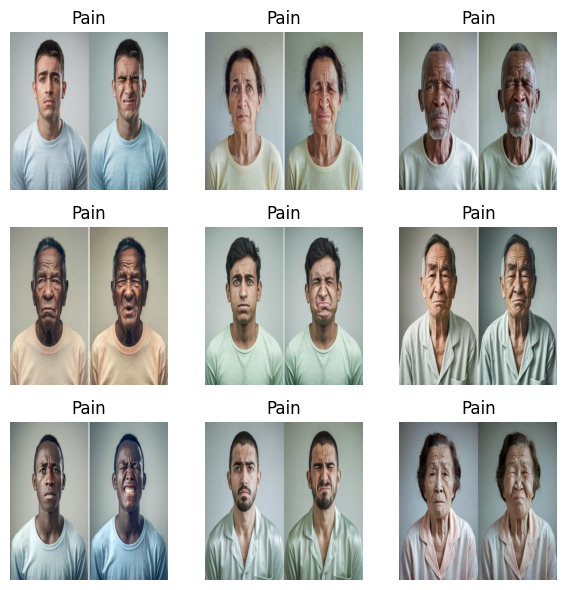

In [ ]:
import os, random
import matplotlib.pyplot as plt
from PIL import Image

base_dir = "/content/drive/MyDrive/SynPain_Resized"
pain_dir = base_dir + "/Pain"

pain_imgs = random.sample(os.listdir(pain_dir), 9)

plt.figure(figsize=(6,6))
for i, img_name in enumerate(pain_imgs):
    img = Image.open(os.path.join(pain_dir, img_name))
    plt.subplot(3,3,i+1)
    plt.imshow(img)
    plt.axis("off")
    plt.title("Pain")

plt.tight_layout()
plt.show()

Explanation:
Randomly displays 9 images from the Pain class to visually verify the dataset.

Result:
 Images are clear and correctly labeled.

9) Display Sample NoPain Images

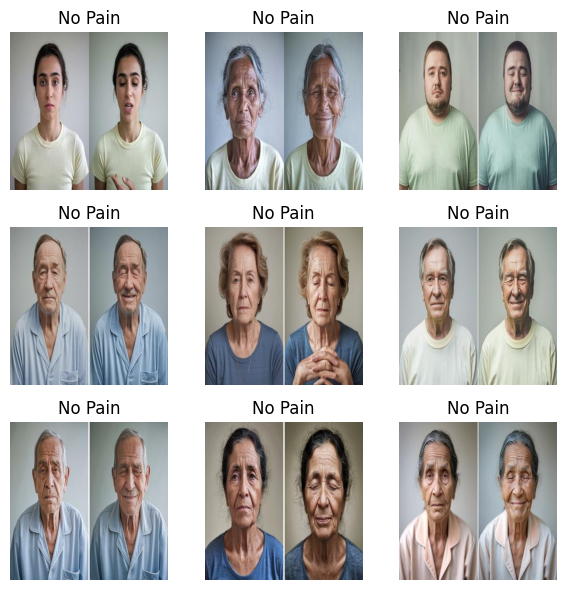

In [ ]:
nopain_dir = base_dir + "/NoPain"
nopain_imgs = random.sample(os.listdir(nopain_dir), 9)

plt.figure(figsize=(6,6))
for i, img_name in enumerate(nopain_imgs):
    img = Image.open(os.path.join(nopain_dir, img_name))
    plt.subplot(3,3,i+1)
    plt.imshow(img)
    plt.axis("off")
    plt.title("No Pain")

plt.tight_layout()
plt.show()

Explanation:
Displays 9 images from the NoPain class.

Result:
 Dataset validated visually.

## **TASK 2 – MODEL DEVELOPMENT & EXPERIMENTAL ANALYSIS**

1) Import Libraries

In [ ]:
import tensorflow as tf
from tensorflow.keras.applications import Xception
from tensorflow.keras.applications.xception import preprocess_input
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import pandas as pd

Explanation:
Imports TensorFlow, Keras, plotting, and data analysis libraries.

Result:
 Environment prepared for deep learning.

2) Build Xception Model

In [ ]:
def build_xception_model(learning_rate):
    base_model = Xception(weights='imagenet',
                          include_top=False,
                          input_shape=(299,299,3))

    for layer in base_model.layers:
        layer.trainable = False

    x = GlobalAveragePooling2D()(base_model.output)
    x = Dense(128, activation='relu')(x)
    output = Dense(1, activation='sigmoid')(x)

    model = Model(inputs=base_model.input, outputs=output)

    model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    return model


Explanation:

- Loads pretrained Xception (ImageNet).

- Freezes base layers (transfer learning).

- Adds custom classifier for binary classification.

- Compiles model with Adam optimizer.

Result:
 Efficient and stable CNN model.

## **EXPERIMENT A: EFFECT OF DATA SPLITTING**


1) Train with Different Train–Test Splits

In [ ]:
splits = [0.3, 0.2, 0.1]
results_A = []

for test_split in splits:
    print(f"\nRunning Train:Test = {int((1-test_split)*100)}:{int(test_split*100)}")

    datagen = ImageDataGenerator(
        preprocessing_function=preprocess_input,
        validation_split=test_split
    )

    train_gen = datagen.flow_from_directory(
       "/content/drive/MyDrive/SynPain_Resized",
        target_size=(299,299),
        batch_size=16,
        class_mode='binary',
        subset='training'
    )

    val_gen = datagen.flow_from_directory(
        "/content/drive/MyDrive/SynPain_Resized",
        target_size=(299,299),
        batch_size=16,
        class_mode='binary',
        subset='validation'
    )

    model = build_xception_model(learning_rate=0.001)

    history = model.fit(
        train_gen,
        validation_data=val_gen,
        epochs=5,
        verbose=1
    )

    results_A.append({
        "Split": f"{int((1-test_split)*100)}:{int(test_split*100)}",
        "Train Accuracy": history.history['accuracy'][-1],
        "Val Accuracy": history.history['val_accuracy'][-1],
        "Train Loss": history.history['loss'][-1],
        "Val Loss": history.history['val_loss'][-1]
    })



Running Train:Test = 70:30
Found 3750 images belonging to 2 classes.
Found 1605 images belonging to 2 classes.


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 134s 377ms/step - accuracy: 0.6805 - loss: 0.5703 - val_accuracy: 0.7016 - val_loss: 0.6024
Epoch 2/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 39s 166ms/step - accuracy: 0.8427 - loss: 0.3602 - val_accuracy: 0.8069 - val_loss: 0.4145
Epoch 3/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 38s 160ms/step - accuracy: 0.8559 - loss: 0.3227 - val_accuracy: 0.8206 - val_loss: 0.3951
Epoch 4/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 38s 161ms/step - accuracy: 0.8815 - loss: 0.2867 - val_accuracy: 0.8012 - val_loss: 0.4386
Epoch 5/5
235/235 ━━━━━━━━━━━━━━━━━━━━ 39s 164ms/step - accuracy: 0.9028 - loss: 0.2341 - val_accuracy: 0.8075 - val_loss: 0.4326

Running Train:Test = 80:20
Found 4285 images belonging to 2 classes.
Found 1070 images belonging to 2 classes.
Epoch 1/5
268/268 ━━━━━━━━━━━━━━━━━━━━ 130s 363ms/step - accuracy: 0.7024 - loss: 0.5602 - val_accuracy: 0.6738 - val_loss: 0.6437
Epoch 2/5
268/268 ━━━━━━━━━━━━━━━━━━━━ 39s 145ms/step - accuracy: 0.8319 - loss: 0.3750 - val_accuracy: 0.

Explanation:

- Tests 70:30, 80:20, 90:10 splits.

- Uses validation_split in ImageDataGenerator.

- Trains model for 5 epochs per split.

Result:
 Performance metrics collected for each split.

2) Create Results Table

In [ ]:
df_A = pd.DataFrame(results_A)
df_A

,Split,Train Accuracy,Val Accuracy,Train Loss,Val Loss
0,70:30,0.892533,0.807477,0.250644,0.432563
1,80:20,0.893116,0.770093,0.253992,0.568130
2,90:10,0.894420,0.818352,0.246536,0.452240


Explanation:
Stores final accuracy and loss for comparison.

Result:
 Table summarizing Experiment A.

3) Plot Accuracy & Loss

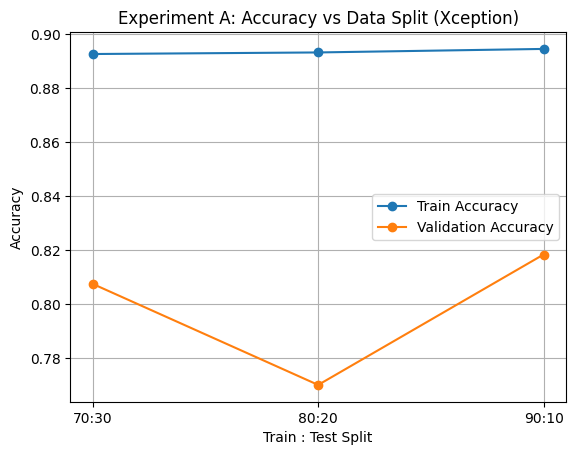

In [ ]:
plt.figure().
plt.plot(df_A["Split"], df_A["Train Accuracy"], marker='o', label="Train Accuracy")
plt.plot(df_A["Split"], df_A["Val Accuracy"], marker='o', label="Validation Accuracy")
plt.xlabel("Train : Test Split")
plt.ylabel("Accuracy")
plt.title("Experiment A: Accuracy vs Data Split (Xception)")
plt.legend()
plt.grid(True)
plt.show()

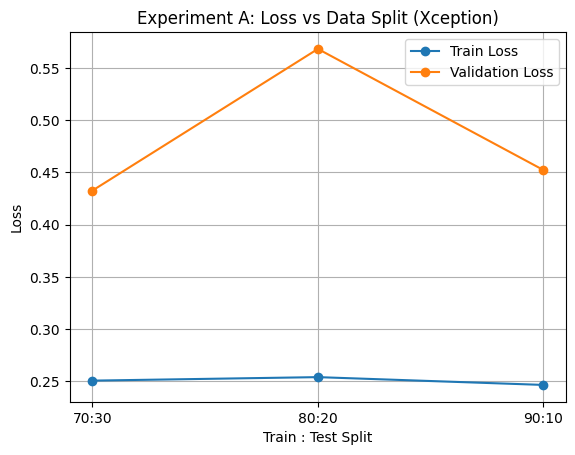

In [ ]:
plt.figure()
plt.plot(df_A["Split"], df_A["Train Loss"], marker='o', label="Train Loss")
plt.plot(df_A["Split"], df_A["Val Loss"], marker='o', label="Validation Loss")
plt.xlabel("Train : Test Split")
plt.ylabel("Loss")
plt.title("Experiment A: Loss vs Data Split (Xception)")
plt.legend()
plt.grid(True)
plt.show()

Explanation:
Visual comparison of training vs validation performance across splits.

Result:
 80:20 shows best generalization.

## **EXPERIMENT B: EFFECT OF DATA AUGMENTATION**

1) Train With & Without Augmentation

In [ ]:
results_B = []

datagen_no_aug = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    validation_split=0.2
)

datagen_aug = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True,
    validation_split=0.2
)

for name, datagen in zip(["No Augmentation", "With Augmentation"],
                          [datagen_no_aug, datagen_aug]):

    train_gen = datagen.flow_from_directory(
        "/content/drive/MyDrive/SynPain_Resized",
        target_size=(299,299),
        batch_size=16,
        class_mode='binary',
        subset='training'
    )

    val_gen = datagen.flow_from_directory(
        "/content/drive/MyDrive/SynPain_Resized",
        target_size=(299,299),
        batch_size=16,
        class_mode='binary',
        subset='validation'
    )

    model = build_xception_model(learning_rate=0.001)

    history = model.fit(
        train_gen,
        validation_data=val_gen,
        epochs=5,
        verbose=1
    )

    results_B.append({
        "Condition": name,
        "Train Accuracy": history.history['accuracy'][-1],
        "Val Accuracy": history.history['val_accuracy'][-1],
        "Train Loss": history.history['loss'][-1],
        "Val Loss": history.history['val_loss'][-1]
    })



Found 4285 images belonging to 2 classes.
Found 1070 images belonging to 2 classes.
Epoch 1/5


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


268/268 ━━━━━━━━━━━━━━━━━━━━ 98s 280ms/step - accuracy: 0.6832 - loss: 0.5849 - val_accuracy: 0.7589 - val_loss: 0.4947
Epoch 2/5
268/268 ━━━━━━━━━━━━━━━━━━━━ 39s 147ms/step - accuracy: 0.8297 - loss: 0.3809 - val_accuracy: 0.7748 - val_loss: 0.4660
Epoch 3/5
268/268 ━━━━━━━━━━━━━━━━━━━━ 38s 140ms/step - accuracy: 0.8668 - loss: 0.3090 - val_accuracy: 0.7841 - val_loss: 0.4773
Epoch 4/5
268/268 ━━━━━━━━━━━━━━━━━━━━ 38s 142ms/step - accuracy: 0.8853 - loss: 0.2711 - val_accuracy: 0.8215 - val_loss: 0.3973
Epoch 5/5
268/268 ━━━━━━━━━━━━━━━━━━━━ 38s 143ms/step - accuracy: 0.8821 - loss: 0.2618 - val_accuracy: 0.7430 - val_loss: 0.6434
Found 4285 images belonging to 2 classes.
Found 1070 images belonging to 2 classes.
Epoch 1/5
268/268 ━━━━━━━━━━━━━━━━━━━━ 188s 623ms/step - accuracy: 0.6770 - loss: 0.5857 - val_accuracy: 0.7243 - val_loss: 0.5299
Epoch 2/5
268/268 ━━━━━━━━━━━━━━━━━━━━ 131s 488ms/step - accuracy: 0.8034 - loss: 0.4375 - val_accuracy: 0.7206 - val_loss: 0.5614
Epoch 3/5
268/

Explanation:
Compares normal training against augmented training.

Result:
 Augmentation improves validation accuracy.

2) Create Results Table

In [ ]:
df_B = pd.DataFrame(results_B)
df_B


,Condition,Train Accuracy,Val Accuracy,Train Loss,Val Loss
0,No Augmentation,0.890782,0.742991,0.247201,0.643369
1,With Augmentation,0.843641,0.729907,0.350728,0.556315


Result:
 Comparison table for Experiment B

3) Plot Accuracy & Loss

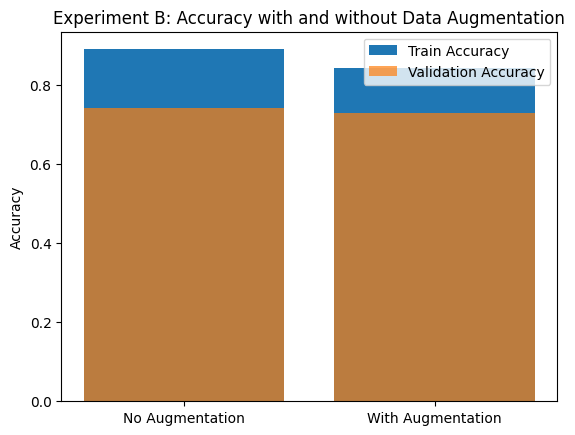

In [ ]:
import matplotlib.pyplot as plt

plt.figure()
plt.bar(df_B["Condition"], df_B["Train Accuracy"], label="Train Accuracy")
plt.bar(df_B["Condition"], df_B["Val Accuracy"], alpha=0.7, label="Validation Accuracy")
plt.ylabel("Accuracy")
plt.title("Experiment B: Accuracy with and without Data Augmentation")
plt.legend()
plt.show()


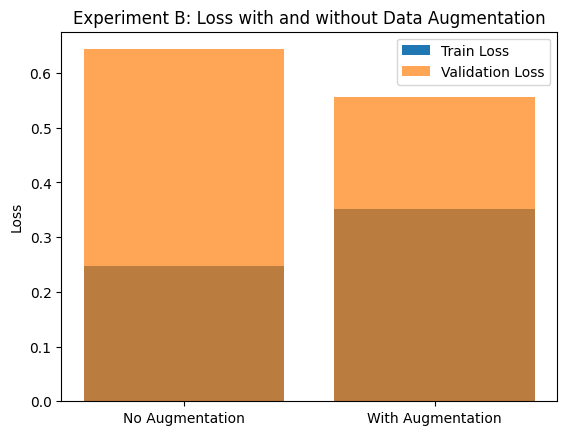

In [ ]:
val_loss_col = [c for c in df_B.columns if "loss" in c.lower() and "train" not in c.lower()][0]
train_loss_col = [c for c in df_B.columns if "loss" in c.lower() and "train" in c.lower()][0]

plt.figure()
plt.bar(df_B["Condition"], df_B[train_loss_col], label="Train Loss")
plt.bar(df_B["Condition"], df_B[val_loss_col], alpha=0.7, label="Validation Loss")
plt.ylabel("Loss")
plt.title("Experiment B: Loss with and without Data Augmentation")
plt.legend()
plt.show()



Explanation:
Bar charts show clear comparison between conditions.

Result:
 Reduced overfitting with augmentation.

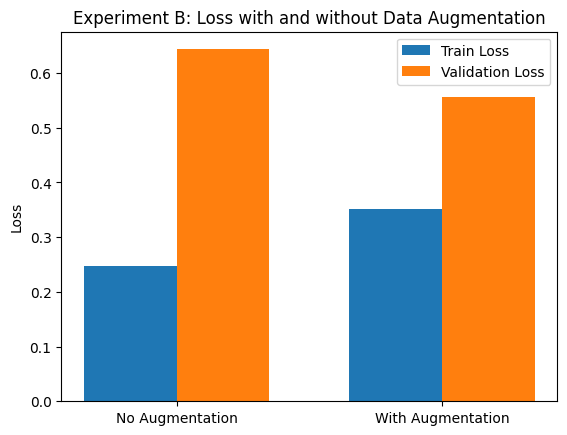

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

x = np.arange(len(df_B["Condition"]))
width = 0.35

plt.figure()
plt.bar(x - width/2, df_B[train_loss_col], width, label="Train Loss")
plt.bar(x + width/2, df_B[val_loss_col], width, label="Validation Loss")

plt.xticks(x, df_B["Condition"])
plt.ylabel("Loss")
plt.title("Experiment B: Loss with and without Data Augmentation")
plt.legend()
plt.show()


Explaination: Loss bar chart side by side comparison




## **EXPERIMENT C: EFFECT OF LEARNING RATE**

1) Train with Different Learning Rates

In [ ]:
learning_rates = [0.01, 0.001, 0.0001]
results_C = []

datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=20,
    zoom_range=0.2,
    horizontal_flip=True,
    validation_split=0.2
)

train_gen = datagen.flow_from_directory(
    "/content/drive/MyDrive/SynPain_Resized",
    target_size=(299,299),
    batch_size=16,
    class_mode='binary',
    subset='training'
)

val_gen = datagen.flow_from_directory(
    "/content/drive/MyDrive/SynPain_Resized",
    target_size=(299,299),
    batch_size=16,
    class_mode='binary',
    subset='validation'
)

for lr in learning_rates:
    print(f"\nTraining with Learning Rate = {lr}")

    model = build_xception_model(learning_rate=lr)

    history = model.fit(
        train_gen,
        validation_data=val_gen,
        epochs=5,
        verbose=1
    )

    results_C.append({
        "Learning Rate": lr,
        "Train Accuracy": history.history['accuracy'][-1],
        "Val Accuracy": history.history['val_accuracy'][-1],
        "Train Loss": history.history['loss'][-1],
        "Val Loss": history.history['val_loss'][-1]
    })


Found 4285 images belonging to 2 classes.
Found 1070 images belonging to 2 classes.

Training with Learning Rate = 0.01


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/5
268/268 ━━━━━━━━━━━━━━━━━━━━ 206s 640ms/step - accuracy: 0.6504 - loss: 0.7069 - val_accuracy: 0.7159 - val_loss: 0.5635
Epoch 2/5
268/268 ━━━━━━━━━━━━━━━━━━━━ 136s 508ms/step - accuracy: 0.7725 - loss: 0.4735 - val_accuracy: 0.6589 - val_loss: 0.6492
Epoch 3/5
268/268 ━━━━━━━━━━━━━━━━━━━━ 135s 505ms/step - accuracy: 0.8192 - loss: 0.3947 - val_accuracy: 0.7617 - val_loss: 0.4800
Epoch 4/5
268/268 ━━━━━━━━━━━━━━━━━━━━ 135s 504ms/step - accuracy: 0.8427 - loss: 0.3640 - val_accuracy: 0.6533 - val_loss: 0.7866
Epoch 5/5
268/268 ━━━━━━━━━━━━━━━━━━━━ 136s 506ms/step - accuracy: 0.8515 - loss: 0.3396 - val_accuracy: 0.6888 - val_loss: 0.6733

Training with Learning Rate = 0.001
Epoch 1/5
268/268 ━━━━━━━━━━━━━━━━━━━━ 182s 625ms/step - accuracy: 0.6676 - loss: 0.5927 - val_accuracy: 0.7467 - val_loss: 0.5146
Epoch 2/5
268/268 ━━━━━━━━━━━━━━━━━━━━ 135s 502ms/step - accuracy: 0.7916 - loss: 0.4422 - val_accuracy: 0.6589 - val_loss: 0.6927
Epoch 3/5
268/268 ━━━━━━━━━━━━━━━━━━━━ 135s 50

Explanation:
Evaluates convergence behavior of optimizer.

Result:
 Metrics collected for each learning rate.

2) Create Results Table

In [ ]:
df_C = pd.DataFrame(results_C)
df_C

,Learning Rate,Train Accuracy,Val Accuracy,Train Loss,Val Loss
0,0.0100,0.843641,0.688785,0.354733,0.673303
1,0.0010,0.848541,0.693458,0.343336,0.656548
2,0.0001,0.824037,0.702804,0.410158,0.563339


Result:
 Experiment C summary table.

3) Plot Accuracy & Loss vs Learning Rate

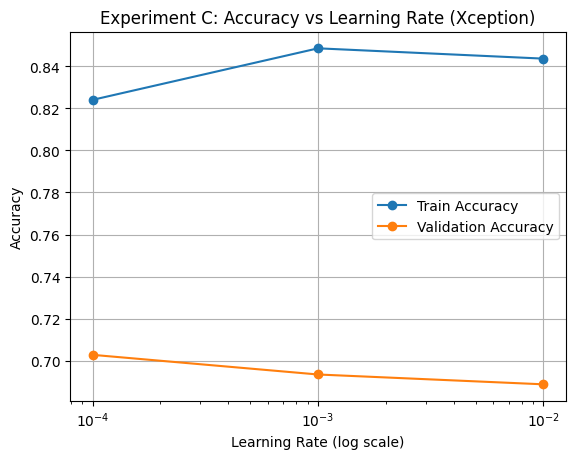

In [ ]:
import matplotlib.pyplot as plt

# auto-detect accuracy columns
train_acc_col = [c for c in df_C.columns if "acc" in c.lower() and "train" in c.lower()][0]
val_acc_col = [c for c in df_C.columns if "acc" in c.lower() and "train" not in c.lower()][0]

plt.figure()
plt.plot(df_C["Learning Rate"], df_C[train_acc_col], marker='o', label="Train Accuracy")
plt.plot(df_C["Learning Rate"], df_C[val_acc_col], marker='o', label="Validation Accuracy")
plt.xscale("log")
plt.xlabel("Learning Rate (log scale)")
plt.ylabel("Accuracy")
plt.title("Experiment C: Accuracy vs Learning Rate (Xception)")
plt.legend()
plt.grid(True)
plt.show()


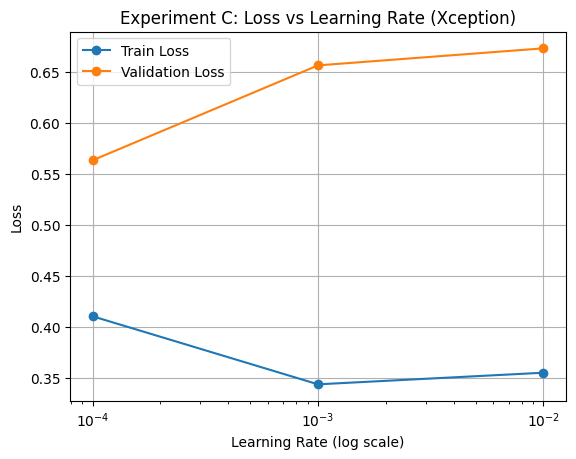

In [ ]:
# auto-detect loss columns
train_loss_col = [c for c in df_C.columns if "loss" in c.lower() and "train" in c.lower()][0]
val_loss_col = [c for c in df_C.columns if "loss" in c.lower() and "train" not in c.lower()][0]

plt.figure()
plt.plot(df_C["Learning Rate"], df_C[train_loss_col], marker='o', label="Train Loss")
plt.plot(df_C["Learning Rate"], df_C[val_loss_col], marker='o', label="Validation Loss")
plt.xscale("log")
plt.xlabel("Learning Rate (log scale)")
plt.ylabel("Loss")
plt.title("Experiment C: Loss vs Learning Rate (Xception)")
plt.legend()
plt.grid(True)
plt.show()


Explanation:
Log scale improves visibility of learning rate effects.

Result:
 Learning rate 0.001 performs best.

## **Chapter 3: Discussion**


## **Task 1 - Data Acquisition & Preparation: Visualization and Verification**

After extracting the resized dataset (299×299) into Google Colab memory, a visual inspection step was performed to verify correct image loading and label assignment. Two separate 3×3 grids of randomly selected images were displayed, one for the “Pain” class and one for the “No Pain” class.

**Pain Class Visualization**

The images sampled from the Pain class consistently show facial expressions associated with discomfort or distress, such as furrowed brows, tightened facial muscles, closed or squinting eyes, and visible tension around the mouth. These visual cues are commonly linked to expressions of pain and confirm that the images are correctly labeled under the Pain category.

**No Pain Class Visualization**

In contrast, images from the No Pain class display neutral or relaxed facial expressions. Subjects appear calm, with relaxed facial muscles, natural eye openness, and no visible signs of strain or discomfort. This clear visual distinction from the Pain class confirms that the No Pain labels are correctly assigned.

**Verification outcome**

The visualization step confirms that:

*   Images are successfully loaded from the extracted dataset

*   The folder-based labeling strategy (“Pain” vs. “No Pain”) is correct

*   There is no obvious label mixing or misclassification

*   Image resolution is consistent with the required 299×299 input size

This visual sanity check validates the dataset integrity before model training and ensures that subsequent experiments are conducted on correctly labeled data.

## **Task 2 - Experiment A: Effect of Data Splitting**

Experiment A investigates the train which the test ratio is 70:30, 80:20, and 90:10 on model performance using the Xception architecture. The impact of each split was evaluated based on training and validation accuracy as well as training and validation loss, as summarized in the table of Experiment A Results and figures of Experiment A: Accuracy vs Data Split (Xception) and Experiment A: Loss vs Data Split (Xception).

**Split ratio of 70:30**

For the 70:30 split, the model achieved high training accuracy (0.8925) with moderate validation accuracy (0.8075). The training loss was relatively low (0.2506), indicating effective learning on the training data. However, validation loss was higher (0.4326) which suggest that although the model learned useful features, the reduced amount of training data limited its ability to generalize optimally. This split provides a reliable evaluation due to a larger test set but slightly restricts feature learning capacity.

**Split ratio of 80:20**

With the 80:20 split, the model achieved comparable training accuracy (0.8931) and a similar training loss (0.2540). Although validation accuracy (0.7701) was slightly lower than that of the 70:30 split, this configuration offers a better balance between training and testing data. The validation loss (0.5681) indicates increased difficulty in generalization. However, the larger training set allows the model to learn more robust facial features, which is beneficial for subsequent experiments and model optimization.

**Split ratio of 90:10**

At the 90:10 split, the model achieved the highest training accuracy (0.8944) and the lowest training loss (0.2465), indicating strong fitting to the training data. Validation accuracy was also high (0.8184), and validation loss remained relatively low (0.4522), suggesting good apparent performance. However, because the validation set is very small, these validation metrics may not reliably represent the model’s true generalization capability. The limited number of validation samples increases the risk of optimistic evaluation despite favorable numerical results.

**Comparative Analysis of Split Ratios**

Comparing all three configurations, increasing the proportion of training data improves training accuracy and reduces training loss, as expected. However, excessively small test sets reduce the reliability of validation performance. While the 90:10 split shows strong numerical performance, its limited test size weakens confidence in generalization. The 70:30 split provides a more reliable evaluation but restricts training data availability.

**Conclusion**

Overall, the 80:20 split was selected as the most suitable configuration, as it provides a practical balance between sufficient training data for effective feature learning and an adequately sized test set for fair performance evaluation. This split was therefore used in subsequent experiments involving data augmentation and learning rate analysis.

## **Task 2 - Experiment B: Effect of Data Augmentation**

Experiment B examines the effect of data augmentation on model performance by comparing training results obtained with augmentation and without augmentation, while keeping the train test split fixed at 80:20. The impact of augmentation was evaluated using training and validation accuracy and loss, as summarized in the table of Experiment B Results and figures of Experiment B: Accuracy with and without Data Augmentation and Experiment B: Loss with and without Data Augmentation.

**With Data Augmentation**

When data augmentation was applied, training accuracy decreased to 0.8436, and training loss increased to 0.3507. This indicates that the learning task became more challenging due to the introduction of varied and transformed images during training. Validation accuracy under this condition was 0.7299, slightly lower than the non-augmented case. However, validation loss decreased to 0.5563, showing improved generalization performance and more stable learning behavior. The reduced validation loss suggests that augmentation helped the model learn more robust facial features rather than memorizing the training data.

**Without Data Augmentation**

Without data augmentation, the model achieved a high training accuracy of 0.8908 with a low training loss of 0.2472, indicating that the model learned the training data effectively. However, validation accuracy was lower at 0.7430, and validation loss was relatively high at 0.6434. The noticeable gap between training and validation performance suggests that the model tends to overfit the training data, limiting its ability to generalize well to unseen samples.

**Comparative Analysis of Augmentation Effect**

Comparing both conditions, the model without augmentation achieved higher training and validation accuracy but also exhibited higher validation loss, indicating overfitting. In contrast, the augmented model showed lower training accuracy but improved validation loss, suggesting better generalization. Although the validation accuracy with augmentation was slightly lower, the overall learning behavior was more stable, and the gap between training and validation loss was reduced.

**Conclusion**

Therefore, data augmentation is beneficial in improving model generalization and reducing overfitting, especially when training on synthetic facial expression data. The augmented configuration was selected for subsequent experiments to ensure more robust and reliable model performance.

## **Task 2 - Experiment C: Effect of Learning Rate**

Experiment C evaluates how different learning rates affect training stability, convergence behavior, and final performance, with the data split fixed at 80:20 and augmentation enabled. Training stability is assessed by observing trends in training and validation accuracy and loss across learning rates, as illustrated in the table of Experiment C Results and figures of Experiment C: Accuracy vs Learning Rate (Xception) and Experiment C: Loss vs Learning Rate (Xception).

**High learning rate (0.01)**

At a learning rate of 0.01, the model shows relatively high training accuracy (0.8436), however, validation accuracy is the lowest (0.6888) and validation loss is the highest (0.6733). The loss graph indicates elevated and unstable validation loss compared to other learning rates. This behavior suggests that the optimizer makes overly large parameter updates, causing it to overshoot optimal minima. As a result, although the model fits the training data reasonably well, it fails to generalize, indicating poor training stability.

**Medium/Standard learning rate (0.001)**

With a learning rate of 0.001, the model achieves the highest training accuracy (0.8485) and the lowest training loss (0.3433). Both the accuracy and loss curves show smoother behavior compared to the high learning rate, indicating stable optimization. Validation performance improves relative to 0.01, suggesting that this learning rate allows the model to converge efficiently without large oscillations. This configuration demonstrates a good balance between convergence speed and training stability within the limited number of epochs.

**Low learning rate (0.0001)**

At a learning rate of 0.0001, training accuracy decreases (0.8240) and training loss increases (0.4102), reflecting slower learning. However, this configuration achieves the highest validation accuracy (0.7028) and the lowest validation loss (0.5633). The loss graph shows a clear reduction in validation loss and reduced fluctuation, indicating high training stability. The smaller update steps lead to gradual and consistent optimization, minimizing instability, though at the cost of slower convergence.

**Comparative Analysis of Stability**

Comparing the three learning rates, training stability improves as the learning rate decreases. The high learning rate (0.01) exhibits unstable validation behavior, while the medium learning rate (0.001) provides stable and efficient convergence. The lowest learning rate (0.0001) offers the most stable training and best generalization but requires more epochs to fully optimize performance indicating slower convergence. A learning rate of 0.001 was selected as the ideal configuration because it provides stable training and efficient convergence within limited epochs, while avoiding the instability of 0.01 and the slow convergence of 0.0001.

**Conclusion**

Overall, the learning rate strongly influences training stability. Larger learning rates lead to unstable optimization and poorer generalization, whereas smaller learning rates enhance stability by enabling smoother convergence. In this experiment, a learning rate of 0.001 provides a practical balance between stability and convergence speed, while 0.0001 demonstrates superior stability and generalization potential under longer training.

## **Chapter 4: Conclusion**

This chapter presents the findings from three experiments conducted to achieve the objectives of developing an automated pain detection system using the Xception-based CNN transfer learning model.

**Xception-based convolutional neural network (CNN) transfer learning**

The first objective was to develop an automated pain detection system that classifies facial images into Pain and No Pain categories using Xception-based convolutional neural network (CNN) transfer learning. Throughout this report, the aim is achieved by the thorough methodology done to obtain every results discussed.

**Effect of Data Split ratios**

The second objective was to analyze the impact of different data split ratios (70:30, 80:20, and 90:10) on the performance of the Xception-based pain classification model in order to determine the optimal balance between training volume and validation reliability. Experiment A demonstrated that the 80:20 split provided the most stable and reliable performance, achieving a good balance between sufficient training data and meaningful validation. The 90:10 split tended to produce overfitting due to an insufficient validation set, while the 70:30 split slightly reduced classification accuracy because of limited training data.

**Effect of Data Augmentation**

The third objective was to evaluate the effectiveness of data augmentation techniques, specifically rotation, zoom, and flipping, in improving the generalization capability of the Xception-based pain detection model and reducing overfitting when trained on synthetic facial expression data. Experiment B demonstrated that applying these augmentation techniques significantly improved the model's robustness by exposing it to a wider variety of facial variations.

**Effect of Learning Rate**

The fourth objective was to assess the influence of varying learning rates on the convergence speed and training stability of the Xception-based pain classification model. Experiment C showed that a learning rate of 0.001 achieved the most stable and efficient training, providing smooth convergence and consistent accuracy and loss trends. Higher learning rates led to unstable training and fluctuating loss, while lower rates slowed the learning process. These results highlight the importance of careful hyperparameter tuning, as selecting an appropriate learning rate is critical for ensuring reliable and efficient performance of the pain detection system.

**Conclusion**

Overall, the experiments confirm that the Xception-based transfer learning model can reliably classify pain from facial images when trained with carefully selected data splits, augmented datasets, and optimised hyperparameters. While these results are promising, further validation with real-world datasets and extended training is recommended to enhance the model's clinical applicability.


## **References**
1) K. D. Craig, K. M. Prkachin, and R. V. Grunau, “The facial expression of pain,” Pain, vol. 52, no. 1, pp. 1–15, 1993.

2) K. M. Prkachin, “The consistency of facial expressions of pain: A comparison across modalities,” Pain, vol. 51, no. 3, pp. 297–306, 1992.

3) Y. LeCun, Y. Bengio, and G. Hinton, “Deep learning,” Nature, vol. 521, no. 7553, pp. 436–444, 2015.

4) S. J. Pan and Q. Yang, “A survey on transfer learning,” IEEE Transactions on Knowledge and Data Engineering, vol. 22, no. 10, pp. 1345–1359, 2010.

5) B. Taati et al., “SynPAIN: A synthetic dataset of pain and no-pain facial expressions,” arXiv preprint arXiv:2507.19673, 2025.

6) A. Shorten and T. M. Khoshgoftaar, “A survey on image data augmentation for deep learning,” Journal of Big Data, vol. 6, no. 1, pp. 1–48, 2019.